# AQI Forecasting — XGBoost Model
**Dataset:** AnandVihar_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** XGBoost with lag features + calendar features + pollutant sub-indices

XGBoost is a gradient-boosted tree ensemble. It cannot natively handle time-series ordering,
so we engineer meaningful features: lagged AQI values, rolling statistics, day-of-week, month, and pollutant levels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')

Libraries loaded successfully.
XGBoost version: 2.1.3


## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('D:/AQI_Project/Data/Final/IITG_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

df = df.drop(columns=['AQI_Category'], errors='ignore')   # ← ADD THIS LINE

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').interpolate(method='time')

daily = df.resample('D').mean().dropna(subset=['AQI'])
print(f'Daily records: {len(daily)}')
print(daily.head())

Daily records: 1200
                 PM25       PM10       NO2       SO2       NH3         CO  \
Timestamp                                                                   
2022-09-19  39.020625  42.679333  3.885000  1.779375  8.885625  10.880000   
2022-09-20  39.020625  42.679333  3.885000  1.779375  8.885625   9.965000   
2022-09-21  34.343750  39.812917  3.698333  1.714167  8.864583  11.104583   
2022-09-22  25.560000  35.793750  3.649583  1.496250  8.433333   8.807917   
2022-09-23  36.077083  44.520909  4.742917  1.454583  5.810833  10.088333   

                   O3        AQI  
Timestamp                         
2022-09-19  12.430000  12.430000  
2022-09-20   9.305417  31.977917  
2022-09-21   9.410000  39.812917  
2022-09-22  11.015833  35.793750  
2022-09-23  10.031667  44.332083  


## 2. Feature Engineering

In [3]:
def create_features(df_in):
    df_f = df_in.copy()

    # Lag features (past AQI values)
    for lag in [1, 2, 3, 7, 14, 30]:
        df_f[f'lag_{lag}'] = df_f['AQI'].shift(lag)

    # Rolling statistics
    df_f['roll_mean_7']  = df_f['AQI'].shift(1).rolling(7).mean()
    df_f['roll_std_7']   = df_f['AQI'].shift(1).rolling(7).std()
    df_f['roll_mean_30'] = df_f['AQI'].shift(1).rolling(30).mean()

    # Calendar features
    df_f['day_of_week'] = df_f.index.dayofweek
    df_f['month']       = df_f.index.month
    df_f['day_of_year'] = df_f.index.dayofyear
    df_f['quarter']     = df_f.index.quarter

    # Cyclical encoding for seasonality
    df_f['month_sin'] = np.sin(2 * np.pi * df_f['month'] / 12)
    df_f['month_cos'] = np.cos(2 * np.pi * df_f['month'] / 12)
    df_f['dow_sin']   = np.sin(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['dow_cos']   = np.cos(2 * np.pi * df_f['day_of_week'] / 7)

    return df_f


featured = create_features(daily)
featured = featured.dropna()  # drop rows with NaN from lag creation

feature_cols = [c for c in featured.columns if c != 'AQI' and c != 'AQI_Category']
print(f'Feature count: {len(feature_cols)}')
print('Features:', feature_cols)

Feature count: 24
Features: ['PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'roll_mean_7', 'roll_std_7', 'roll_mean_30', 'day_of_week', 'month', 'day_of_year', 'quarter', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


## 3. Train/Test Split (Temporal)

In [4]:
split_date = '2025-07-01'
train = featured[:split_date].iloc[:-1]
test  = featured[split_date:]

X_train = train[feature_cols]
y_train = train['AQI']
X_test  = test[feature_cols]
y_test  = test['AQI']

print(f'Train: {len(train)} | Test: {len(test)}')

Train: 986 | Test: 184


## 4. Train XGBoost Model

In [5]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='rmse'
)

# Time-based validation split from train
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'Best iteration: {model.best_iteration}')

[0]	validation_0-rmse:75.74839
[50]	validation_0-rmse:19.10433
[100]	validation_0-rmse:8.81741
[150]	validation_0-rmse:7.36838
[200]	validation_0-rmse:7.10077
[250]	validation_0-rmse:7.01669
[300]	validation_0-rmse:6.98576
[350]	validation_0-rmse:6.98745
[354]	validation_0-rmse:6.98682
Best iteration: 325


## 5. Forecast & Evaluation

Note: Features that use lagged AQI will use *actual* test values for a fair direct evaluation.
For truly recursive forecasting, see the cell below.

In [6]:
# Direct forecast (uses actual test-period lag values)
pred_direct = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_direct))
mae  = mean_absolute_error(y_test, pred_direct)
mape = np.mean(np.abs((y_test.values - pred_direct) / y_test.values)) * 100

print(f'XGBoost Direct Forecast:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')

XGBoost Direct Forecast:
  RMSE : 3.09
  MAE  : 2.23
  MAPE : 4.09%


In [7]:
# Recursive (multi-step ahead) forecast — uses predicted values as lag inputs
def recursive_forecast(model, train_df, test_df, feature_cols, lag_cols):
    all_data = pd.concat([train_df, test_df])
    all_data = all_data.copy()
    predictions = []

    for i in range(len(train_df), len(all_data)):
        row = all_data.iloc[i]
        feat = row[feature_cols].values.reshape(1, -1)
        pred = model.predict(feat)[0]
        predictions.append(pred)
        # Update lag columns in subsequent rows
        if i + 1 < len(all_data):
            for lag_col in lag_cols:
                lag_n = int(lag_col.split('_')[1])
                if i + 1 - len(train_df) >= lag_n:
                    all_data.at[all_data.index[i+1], lag_col] = predictions[-lag_n]

    return np.array(predictions)

lag_cols = [c for c in feature_cols if c.startswith('lag_')]
pred_recursive = recursive_forecast(model, train, test, feature_cols, lag_cols)

rmse_r = np.sqrt(mean_squared_error(y_test, pred_recursive))
mae_r  = mean_absolute_error(y_test, pred_recursive)
print(f'XGBoost Recursive Forecast: RMSE={rmse_r:.2f}  MAE={mae_r:.2f}')

XGBoost Recursive Forecast: RMSE=3.57  MAE=2.51


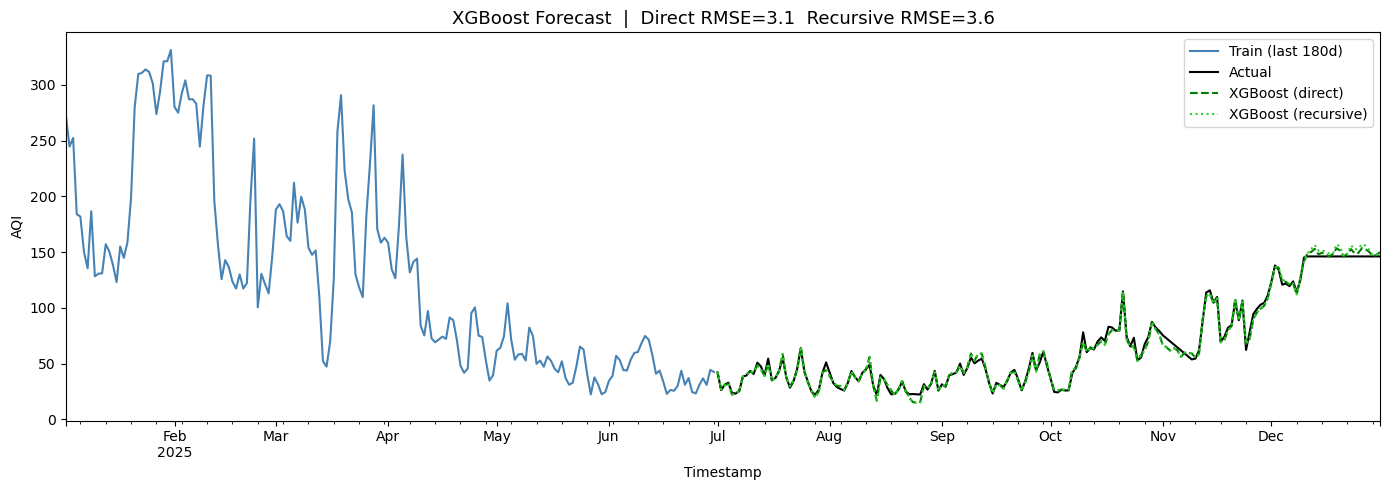

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
y_train[-180:].plot(ax=ax, label='Train (last 180d)', color='steelblue')
y_test.plot(ax=ax, label='Actual', color='black', linewidth=1.5)
ax.plot(y_test.index, pred_direct, label='XGBoost (direct)', color='green', linestyle='--')
ax.plot(y_test.index, pred_recursive, label='XGBoost (recursive)', color='limegreen', linestyle=':')
ax.set_title(f'XGBoost Forecast  |  Direct RMSE={rmse:.1f}  Recursive RMSE={rmse_r:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('xgboost_forecast_IITG.png', dpi=150)
plt.show()

## 6. Feature Importance

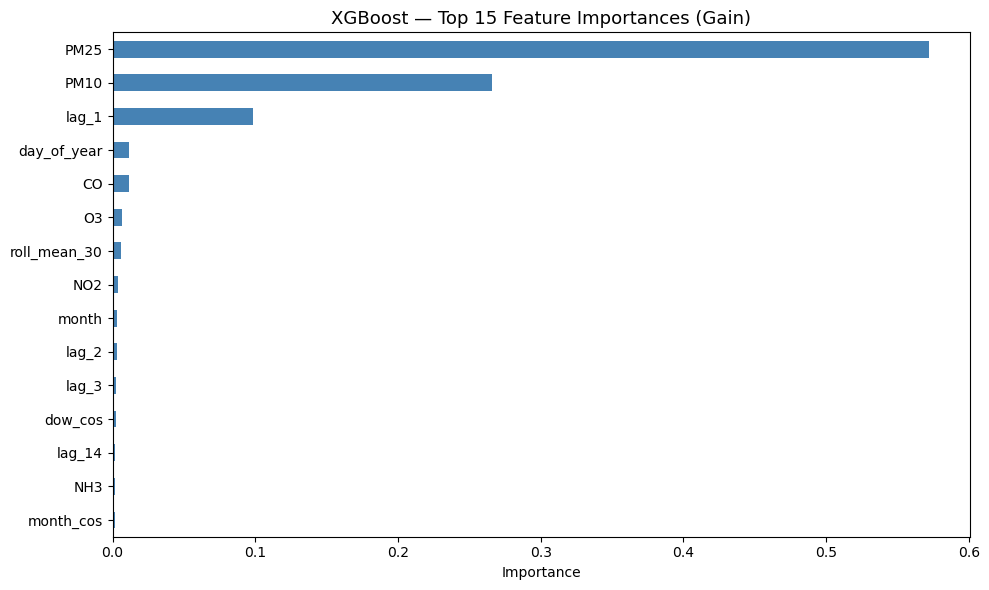

PM25            0.572158
PM10            0.266190
lag_1           0.098561
day_of_year     0.011753
CO              0.011258
O3              0.006717
roll_mean_30    0.005601
NO2             0.003530
month           0.003027
lag_2           0.002896
dtype: float32


In [9]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('XGBoost — Top 15 Feature Importances (Gain)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('xgboost_feature_importance_IITG.png', dpi=150)
plt.show()
print(importance.head(10))

## 7. Learning Curve

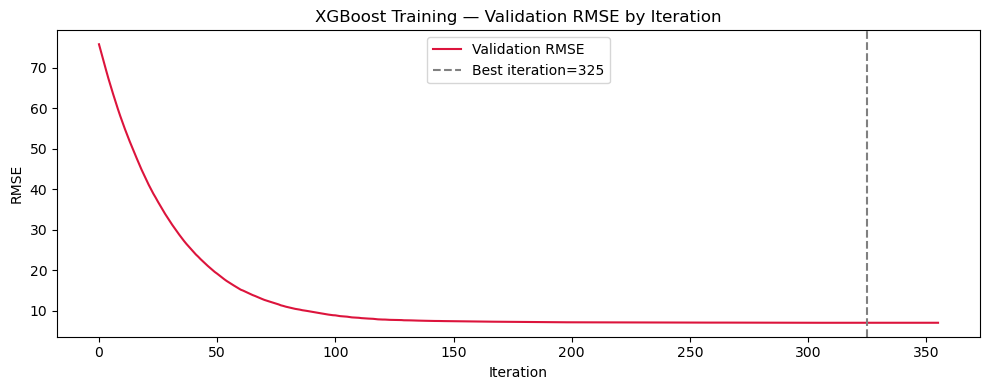

In [10]:
evals_result = model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals_result['validation_0']['rmse'], label='Validation RMSE', color='crimson')
ax.axvline(model.best_iteration, linestyle='--', color='gray', label=f'Best iteration={model.best_iteration}')
ax.set_title('XGBoost Training — Validation RMSE by Iteration')
ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig('xgboost_learning_curve_IITG.png', dpi=150)
plt.show()

In [ ]:
import joblib, os
os.makedirs("D:/AQI_Project/models", exist_ok=True)
joblib.dump(model, "D:/AQI_Project/models/Guwahati_xgboost_aqi.pkl")

['D:/AQI_Project/models/Guwahati_xgboost_aqi.pkl']

: 